## What is Accuracy in Classification?

Accuracy is one of the most common evaluation metrics for classification models.
$$
Accuracy=\frac{Number of Correct Predictions}{Total Number of predictions}$$

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$
Example: Medical Screening for Cancer

True Positive (TP): Patient has cancer → test says cancer 

True Negative (TN): Patient is healthy → test says healthy 

False Negative (FN): Patient has cancer → test says healthy  (very dangerous, missed diagnosis)

False Positive (FP): Patient is healthy → test says cancer 



Example

Suppose we test a model on 100 samples:

TP = 40 (correctly predicted positives)

TN = 50 (correctly predicted negatives)

FP = 5 (wrongly predicted positive)

FN = 5 (wrongly predicted negative)

$$

Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
\frac{40+50}{40+50+5+5}
=\frac{90}{100}=0.9
$$

## Limitation of Accuracy

Accuracy can be misleading when the data is <b>imbalanced</b> (i.e., one class is much more frequent).

Example:
If 95% of samples are "Negative" and only 5% are "Positive," a dumb model that always predicts Negative will get 95% accuracy - but it fails to detect positives. 

Example:

Consider a spam detection model:

You have 1,000 emails.

990 are not spam (negative class).

10 are spam (positive class).

A simple model that always predicts "not spam" would achieve an accuracy of 990 / 1000 = 99%. This sounds great, but the model is completely useless because it failed to identify a single spam email. This is known as the *accuracy paradox*. In such cases, other metrics like precision, recall, and the F1-score provide a more complete picture of the model's performance.

That’s why, in imbalanced datasets, we also look at:

- Precision (how many predicted positives are correct)

- Recall (how many actual positives are detected)

- F1-score (balance between precision & recall)

Accuracy is Good when classes are balanced.
For imbalanced datasets, rely on precision, recall, F1, ROC-AUC instead of only accuracy

### Precision
- Among all predicted positive classes,how many are actual positives.
$$
 Precision=\frac{TP}{TP+FP} 
 $$

- It is the accuracy of a model's positive predictions.
- Of all the items the model labeled as positive, how many were actually positive?" 
- A high precision score indicates a low rate of false positives

Suppose we are building a spam classifier:

Predicted Spam (positive) → 90 emails.

Out of these 90, 80 were actually spam (TP) and 10 were not spam (FP).
$$
Precision=\frac{80}{80+10}=\frac{80}{90}=0.88
$$
### When to Focus on Precision

When false positives are more harmful than false negatives.
- Example: In email spam detection, we don’t want important emails marked as spam.
- Example: In medical diagnosis, misdiagnosing a healthy person as sick could cause unnecessary stress and treatment.

In [10]:
from sklearn.metrics import precision_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

# Load dataset
X, y = load_breast_cancer(return_X_y=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)


Precision: 0.9814814814814815


 ## Recall
 -it answers the question: "Out of all the actual positive cases, what proportion did the model correctly identify?"  
 $$ 
 Recall=\frac{TP}{TP+FN} 
 $$

Say you have 200 patients:

- 100 are actually sick (actual positives = 100).

- 100 are actually healthy (actual negatives = 100).

Suppose your model:

- Predicts 90 patients as sick (predicted positives = 90).

- Of those 90 predicted sick, 80 are actually sick → TP = 80.

- The remaining 10 of those 90 are healthy but labelled sick → FP = 10.

Because there were 100 actual sick and TP = 80, the model missed 20 sick patients → FN = 20.
### When Recall Matters Most

You care about recall when missing a positive case is very costly.

- Medical diagnosis: Failing to detect a disease (false negative) could be deadly.

- Fraud detection: Missing a fraudulent transaction is dangerous.

- Search engines: You want to retrieve as many relevant documents as possible.

In [11]:
from sklearn.metrics import recall_score
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)


Recall: 0.9814814814814815


### F1 Score

The F1-score is the harmonic mean of precision and recall.
$$
F1-Score=2*\frac{Precision*Recall}{Precision+Recall}
$$
- It balances precision (avoiding false positives) and recall (avoiding false negatives).

### Why is it useful?
The F1 score is particularly valuable when you're working with imbalanced datasets, where one class is much more frequent than the other. In such cases, a simple accuracy metric can be misleading.
- The F1 score helps you avoid this "accuracy paradox" by penalizing models that have a poor performance on either precision or recall. 
- It gives equal weight to both false positives (Type I errors) and false negatives (Type II errors).

In [12]:
from sklearn.metrics import f1_score
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Recall
recall = f1_score(y_test, y_pred)
print("F1-Score:", recall)


F1-Score: 0.9814814814814815


In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        63
           1       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Generate Synthetic Data
# We'll create a simple dataset with two features and a binary target variable.
# The `make_classification` function is great for this.
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    flip_y=0.1,  # Add a little noise
    random_state=42
)

# 2. Split Data into Training and Testing Sets
# It's crucial to split your data to evaluate the model's performance on unseen data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Create and Train the Logistic Regression Model
# Initialize the model and train it using the training data.
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Make Predictions
# Use the trained model to make predictions on the test data.
y_pred = model.predict(X_test)

# 5. Evaluate the Model's Performance
# We can evaluate how well our model did using several metrics.
print("Accuracy:", )
accuracy_score(y_test, y_pred)


Accuracy:


0.88

In [15]:
print("\nConfusion Matrix:\n",)
confusion_matrix(y_test, y_pred)


Confusion Matrix:



array([[120,  16],
       [ 20, 144]], dtype=int64)

In [16]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87       136
           1       0.90      0.88      0.89       164

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300



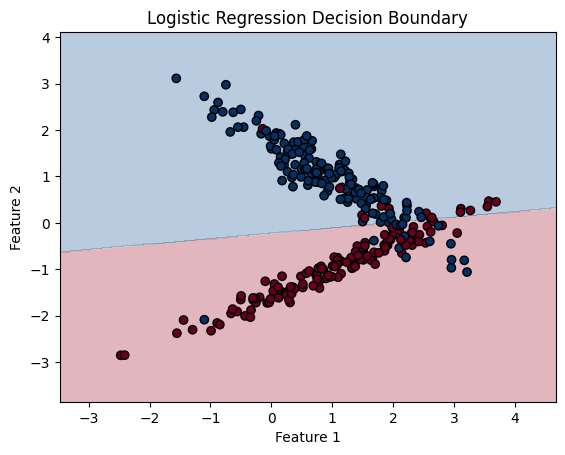

In [17]:

# 6. Visualize the Results
# Plotting the decision boundary helps visualize how the model separates the classes.
def plot_decision_boundary(X, y, model):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k')
    plt.title("Logistic Regression Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(X_test, y_test, model)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
df=pd.read_csv("Train.csv")  
df.drop("ID",

 axis=1, inplace=True) 
target=df["Reached.on.Time_Y.N"]
df.drop("Reached.on.Time_Y.N", axis=1, inplace=True) 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["Customer_care_calls","Customer_rating","Cost_of_the_Product","Prior_purchases","Discount_offered","Weight_in_gms"]] = scaler.fit_transform(df[["Customer_care_calls","Customer_rating","Cost_of_the_Product","Prior_purchases","Discount_offered","Weight_in_gms"]])

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(sparse_output=False,drop="first")
encoded = encoder.fit_transform(df[["Warehouse_block","Mode_of_Shipment","Product_importance","Gender"]])

df_encoded = pd.DataFrame(encoded,columns = encoder.get_feature_names_out())
df = pd.concat([df,df_encoded],axis=1)

df.drop(["Warehouse_block","Mode_of_Shipment","Product_importance","Gender"],axis=1,inplace=True)

df

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,-0.047711,-0.700755,-0.690722,-0.372735,1.889983,-1.468240,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.047711,1.421578,0.120746,-1.029424,2.815636,-0.333893,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
2,-1.799887,-0.700755,-0.565881,0.283954,2.136824,-0.159002,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-0.923799,0.006689,-0.711529,0.283954,-0.208162,-1.502484,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,-1.799887,-0.700755,-0.545074,-0.372735,2.013404,-0.703244,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,-0.047711,-1.408199,0.869792,0.940643,-0.763553,-1.281730,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
10995,-0.047711,-1.408199,0.453655,0.940643,-0.455002,-1.459679,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
10996,0.828377,0.714133,0.661724,0.940643,-0.578423,-1.515937,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
10997,0.828377,-0.700755,0.266394,1.597332,-0.701843,-1.482304,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0


In [7]:
from sklearn.model_selection import train_test_split

X = df  # features
y=target        # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y) 
X


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,-0.047711,-0.700755,-0.690722,-0.372735,1.889983,-1.468240,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.047711,1.421578,0.120746,-1.029424,2.815636,-0.333893,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
2,-1.799887,-0.700755,-0.565881,0.283954,2.136824,-0.159002,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-0.923799,0.006689,-0.711529,0.283954,-0.208162,-1.502484,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,-1.799887,-0.700755,-0.545074,-0.372735,2.013404,-0.703244,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,-0.047711,-1.408199,0.869792,0.940643,-0.763553,-1.281730,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
10995,-0.047711,-1.408199,0.453655,0.940643,-0.455002,-1.459679,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
10996,0.828377,0.714133,0.661724,0.940643,-0.578423,-1.515937,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
10997,0.828377,-0.700755,0.266394,1.597332,-0.701843,-1.482304,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", )
accuracy_score(y_test, y_pred)

Accuracy:


0.6386363636363637